In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from datetime import timedelta
from etl.customer import aggregate_customer
from etl.subsidy import report_customer_conversion_by_subsidy_issue_status, report_customer_metrics_by_subsidy_issue_status
from etl.subsidy import visualize_conversion_by_subsidy_issues, report_customer_subsidy_issues_by_product
from etl.subsidy import visualize_customer_subsidy_issues_by_product
from etl.price import visualize_conversion_by_price_sweet_spots, visualize_conversion_by_price_sweet_spots_variant
from etl.price import report_product_conversion_by_price_quartile, visualize_conversion_by_equipment_category_price
from etl.price import visualise_conversion_by_brand_price

import warnings
warnings.filterwarnings('ignore')

df_clean = pd.read_csv('cleaned_quote_data.csv')
df_clean['dt_creation_devis'] = pd.to_datetime(df_clean['dt_creation_devis'])
print(f"Loaded data: {len(df_clean):,} quotes from {df_clean['numero_compte'].nunique():,} customers")

Loaded data: 34,014 quotes from 23,888 customers


In [2]:
#customers = aggregate_customer(df_clean)

In [3]:
customers = pd.read_csv('customer_master_data.csv')


Customer conversion by subsidy issue status:

                   conversion_rate  customer_count  converted_count
had_subsidy_issue                                                  
False                     0.362042           17335           6276.0
True                      0.485579            6553           3182.0

Chi-square p-value: 7.601147e-68
Statistically significant: YES

Conversion without issues: 36.20%
Conversion with issues: 48.56%
Difference: 12.4 percentage points
Customer-level finding: +12.4 points

Customer characteristics by subsidy issue status

Metric comparison:

total_quotes:
  No issues: 1.38
  With issues: 1.53
  Ratio: 1.11x

avg_quote_amount:
  No issues: 6164.43
  With issues: 9935.00
  Ratio: 1.61x

max_quote_amount:
  No issues: 6571.38
  With issues: 10832.75
  Ratio: 1.65x

customer_duration_days:
  No issues: 17.87
  With issues: 24.31
  Ratio: 1.36x

price_range:
  No issues: 868.91
  With issues: 1702.03
  Ratio: 1.96x

multiple_quotes:
  No issues: 

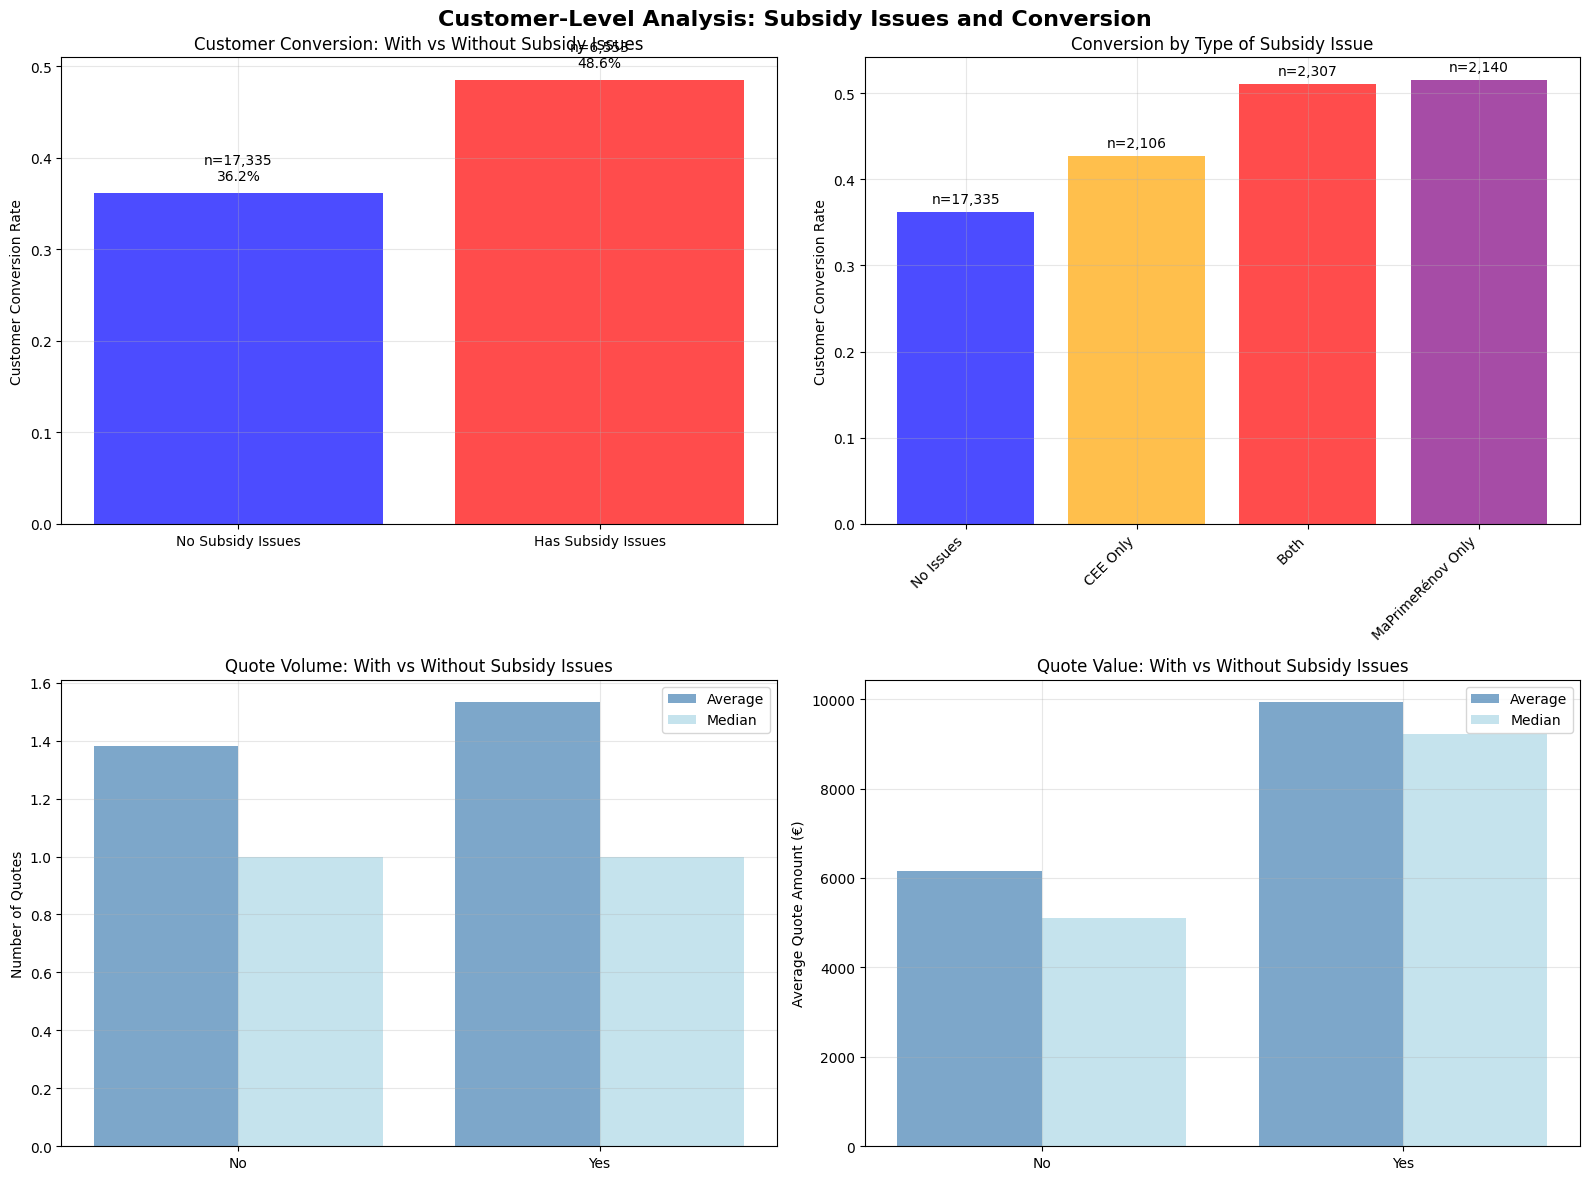

In [4]:
conv_no_issue, conv_with_issue = report_customer_conversion_by_subsidy_issue_status(customers)
report_customer_metrics_by_subsidy_issue_status(customers)
visualize_conversion_by_subsidy_issues(customers, conv_no_issue, conv_with_issue)

Unique values in main_product_family:
main_product_family
Chaudière                           7430
Poêle                               5431
Climatisation                       4573
Pompe à chaleur                     4090
ECS : Chauffe-eau ou adoucisseur    1060
Photovoltaïque                       549
Autres                               270
Appareil hybride                     151
Plomberie Sanitaire                  103
Emetteur de chauffage  ou chappe      93
Produit VMC                           89
Unknown                               36
Fumisterie                            13
Name: count, dtype: int64

Top products:
main_product_family
Chaudière                           7430
Poêle                               5431
Climatisation                       4573
Pompe à chaleur                     4090
ECS : Chauffe-eau ou adoucisseur    1060
Photovoltaïque                       549
Autres                               270
Appareil hybride                     151
Plomberie Sanitaire 

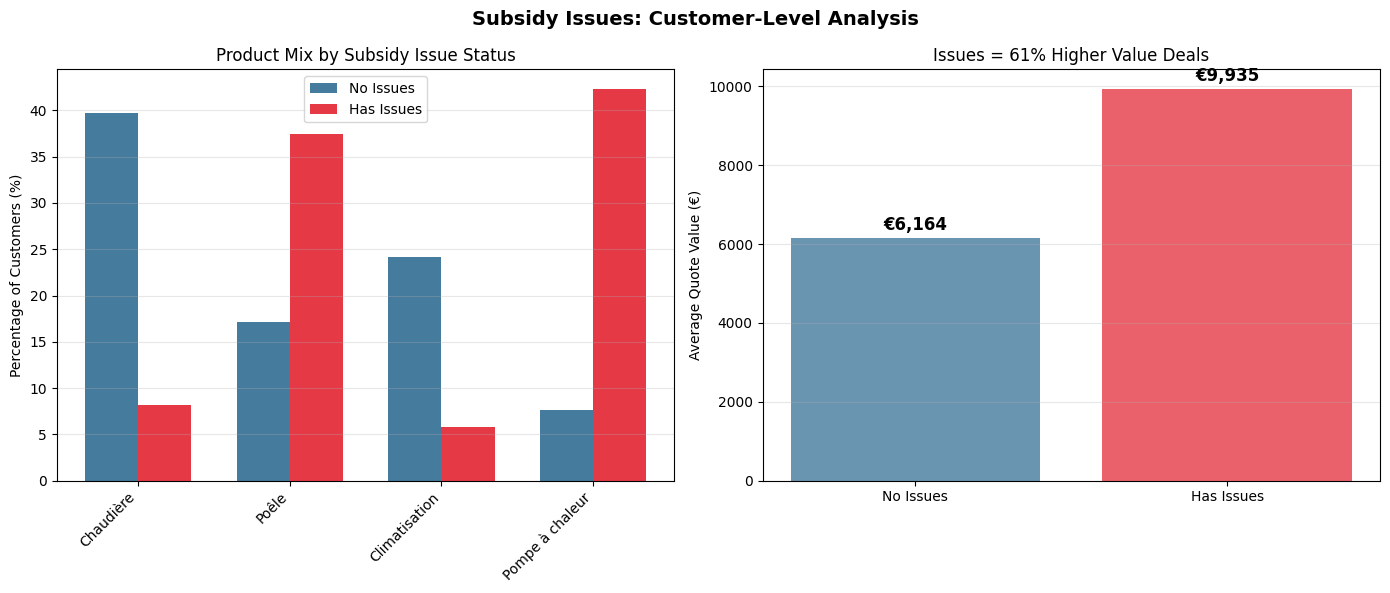

In [5]:
top_products, no_issue_pct, issue_pct = report_customer_subsidy_issues_by_product(customers)
visualize_customer_subsidy_issues_by_product(customers, top_products, no_issue_pct, issue_pct)


Threshold effect

Analyzing 22,308 customers
Price range: €1,339 to €28,212
Median price: €6,321


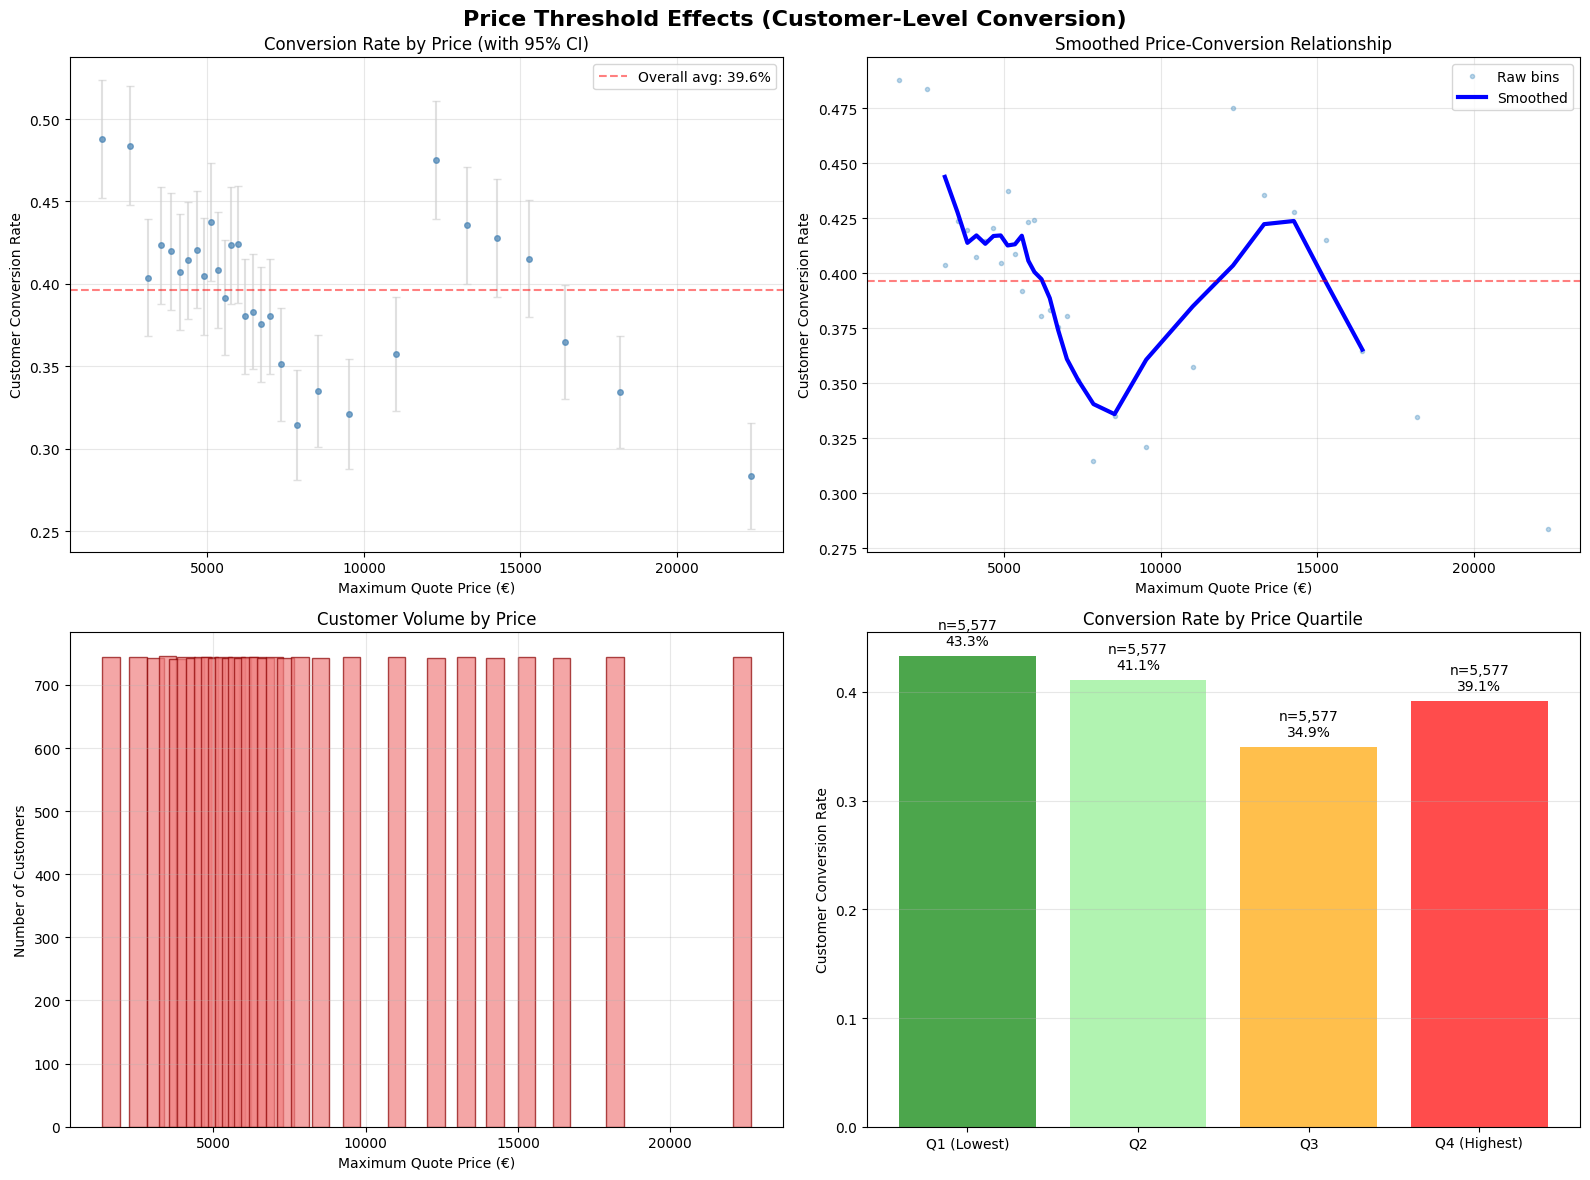


THRESHOLD EFFECT: KEY FINDINGS

Conversion by Price Quartile:
  Q1 (Lowest): 43.3% (n=5,577)
  Q2: 41.1% (n=5,577)
  Q3: 34.9% (n=5,577)
  Q4 (Highest): 39.1% (n=5,577)

Difference between lowest and highest quartile: 4.2 percentage points

Sweet spots (above-average conversion):
  €1,643: 48.8% (n=744)
  €2,523: 48.4% (n=744)
  €3,102: 40.4% (n=743)
  €3,506: 42.4% (n=746)
  €3,822: 42.0% (n=741)
  €4,110: 40.7% (n=744)
  €4,393: 41.4% (n=743)
  €4,654: 42.1% (n=744)
  €4,884: 40.5% (n=744)
  €5,107: 43.7% (n=743)
  €5,341: 40.9% (n=744)
  €5,769: 42.3% (n=744)
  €5,963: 42.4% (n=743)
  €12,305: 47.5% (n=743)
  €13,300: 43.5% (n=744)
  €14,250: 42.8% (n=743)
  €15,283: 41.5% (n=744)

Analyzing 22,308 customers
Price range: €1,339 to €28,212
Median price: €6,321

Product mix by price quartile

Product distribution by price quartile (%):
main_equipment_category    AC  Boiler  Heat Pump  Other  Stove  Unknown
price_quartile                                                         
Q1_Low

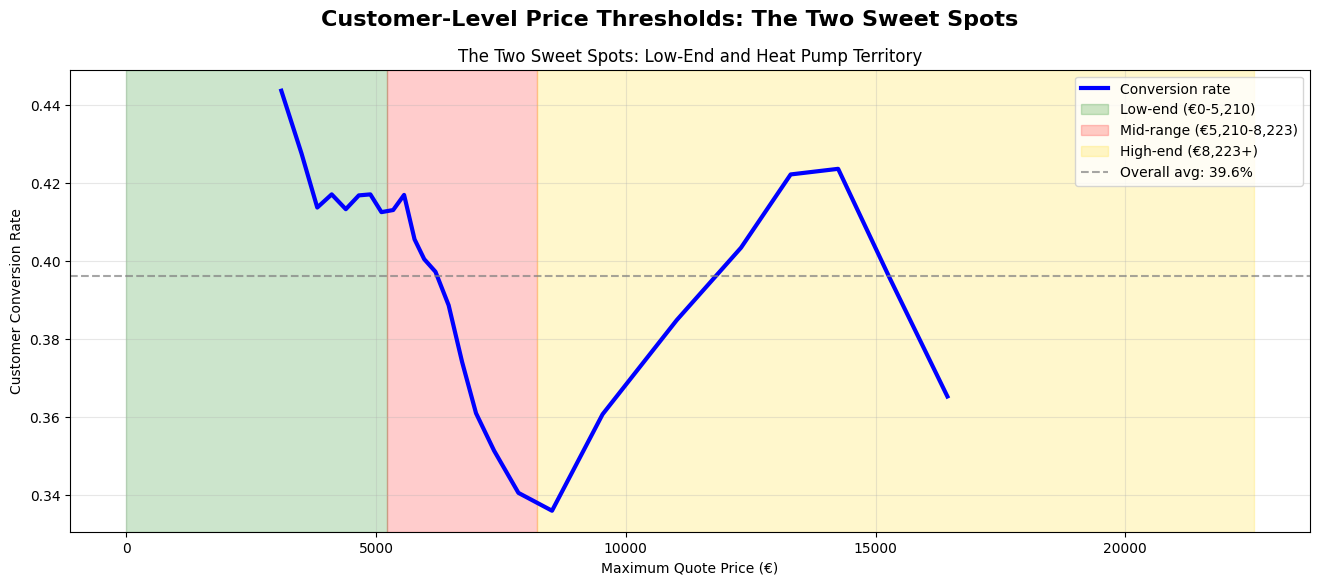

In [6]:
visualize_conversion_by_price_sweet_spots(customers, price_var='max_out_of_pocket')
visualize_conversion_by_price_sweet_spots_variant(customers, price_var='max_out_of_pocket')
report_product_conversion_by_price_quartile(customers)


Equipment Category Segment Effect

Analyzing 22,308 customers
Price range: €1,339 to €28,212
Median price: €6,321


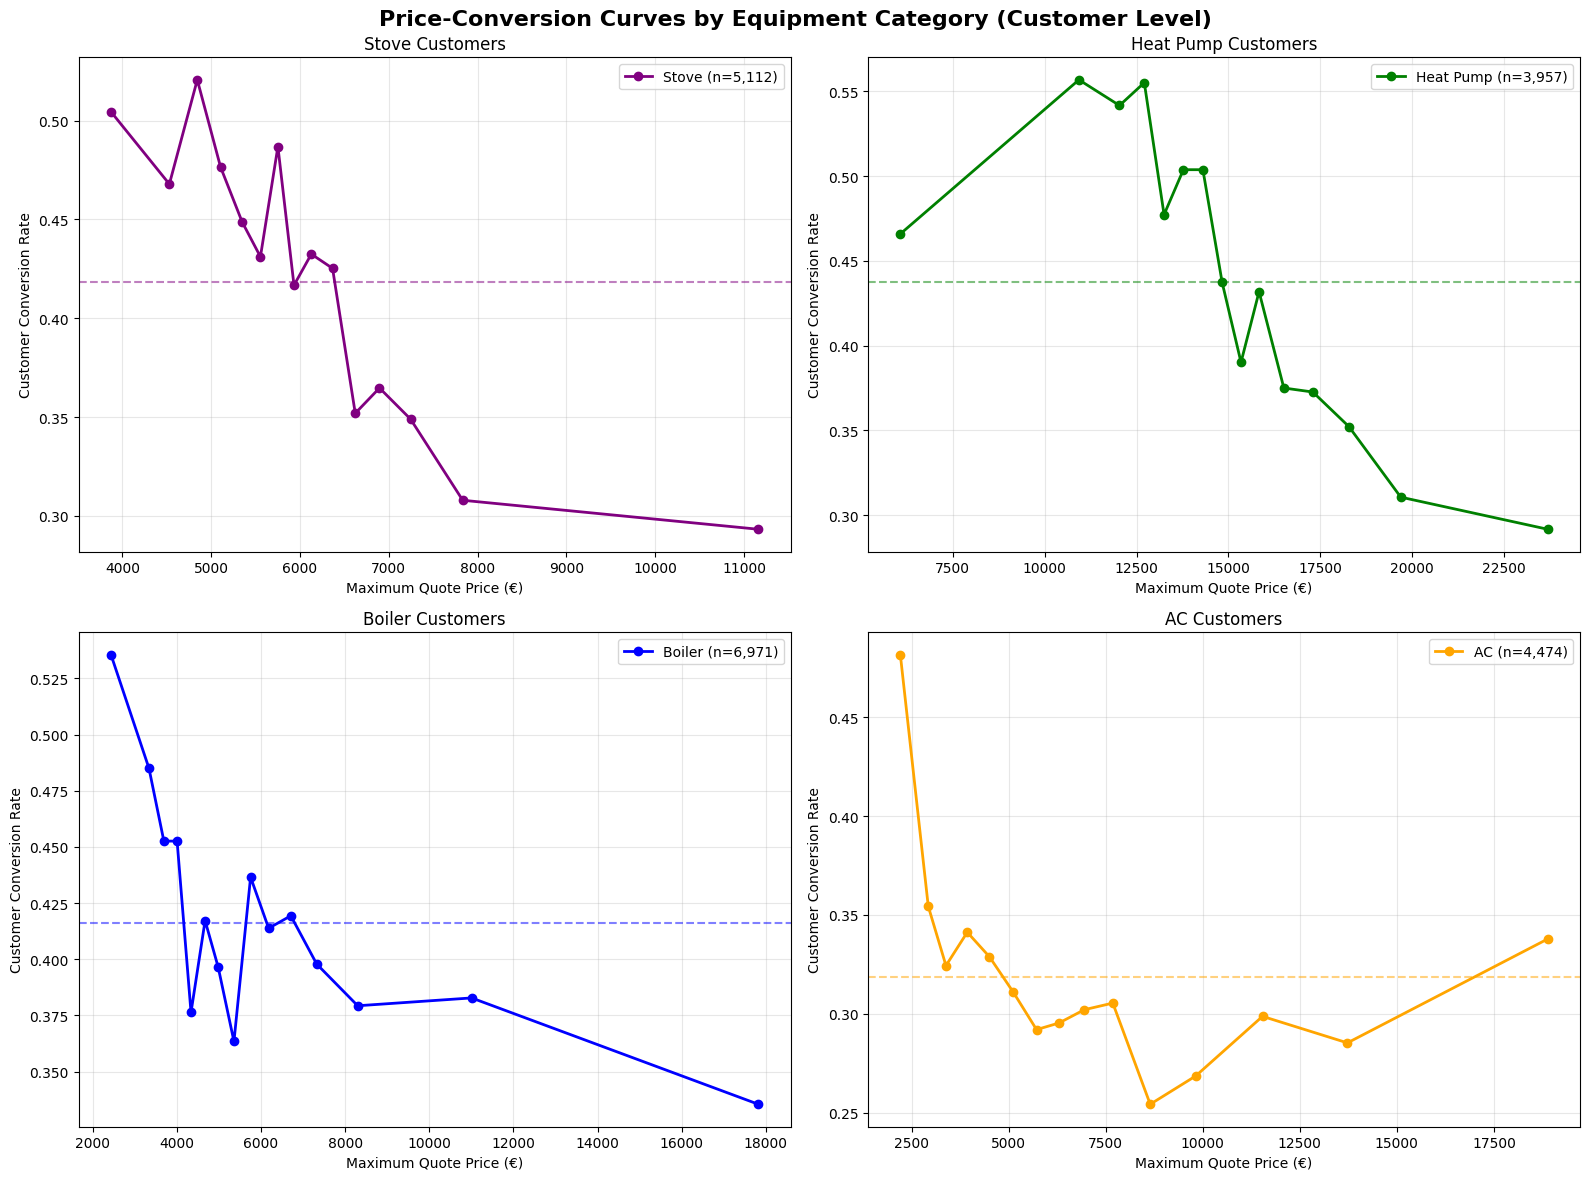

In [7]:
visualize_conversion_by_equipment_category_price(customers, price_var='max_out_of_pocket')


Conversion by Brand Price

Analyzing 22,308 customers
Price range: €1,339 to €28,212
Median price: €6,321
Top 8 brands: ['ATLANTIC', 'MITSUBISHI ELECTRIC', 'MCZ', 'E.L.M. LEBLANC', 'FRISQUET', 'SAUNIER DUVAL', 'DE DIETRICH', 'HITACHI']


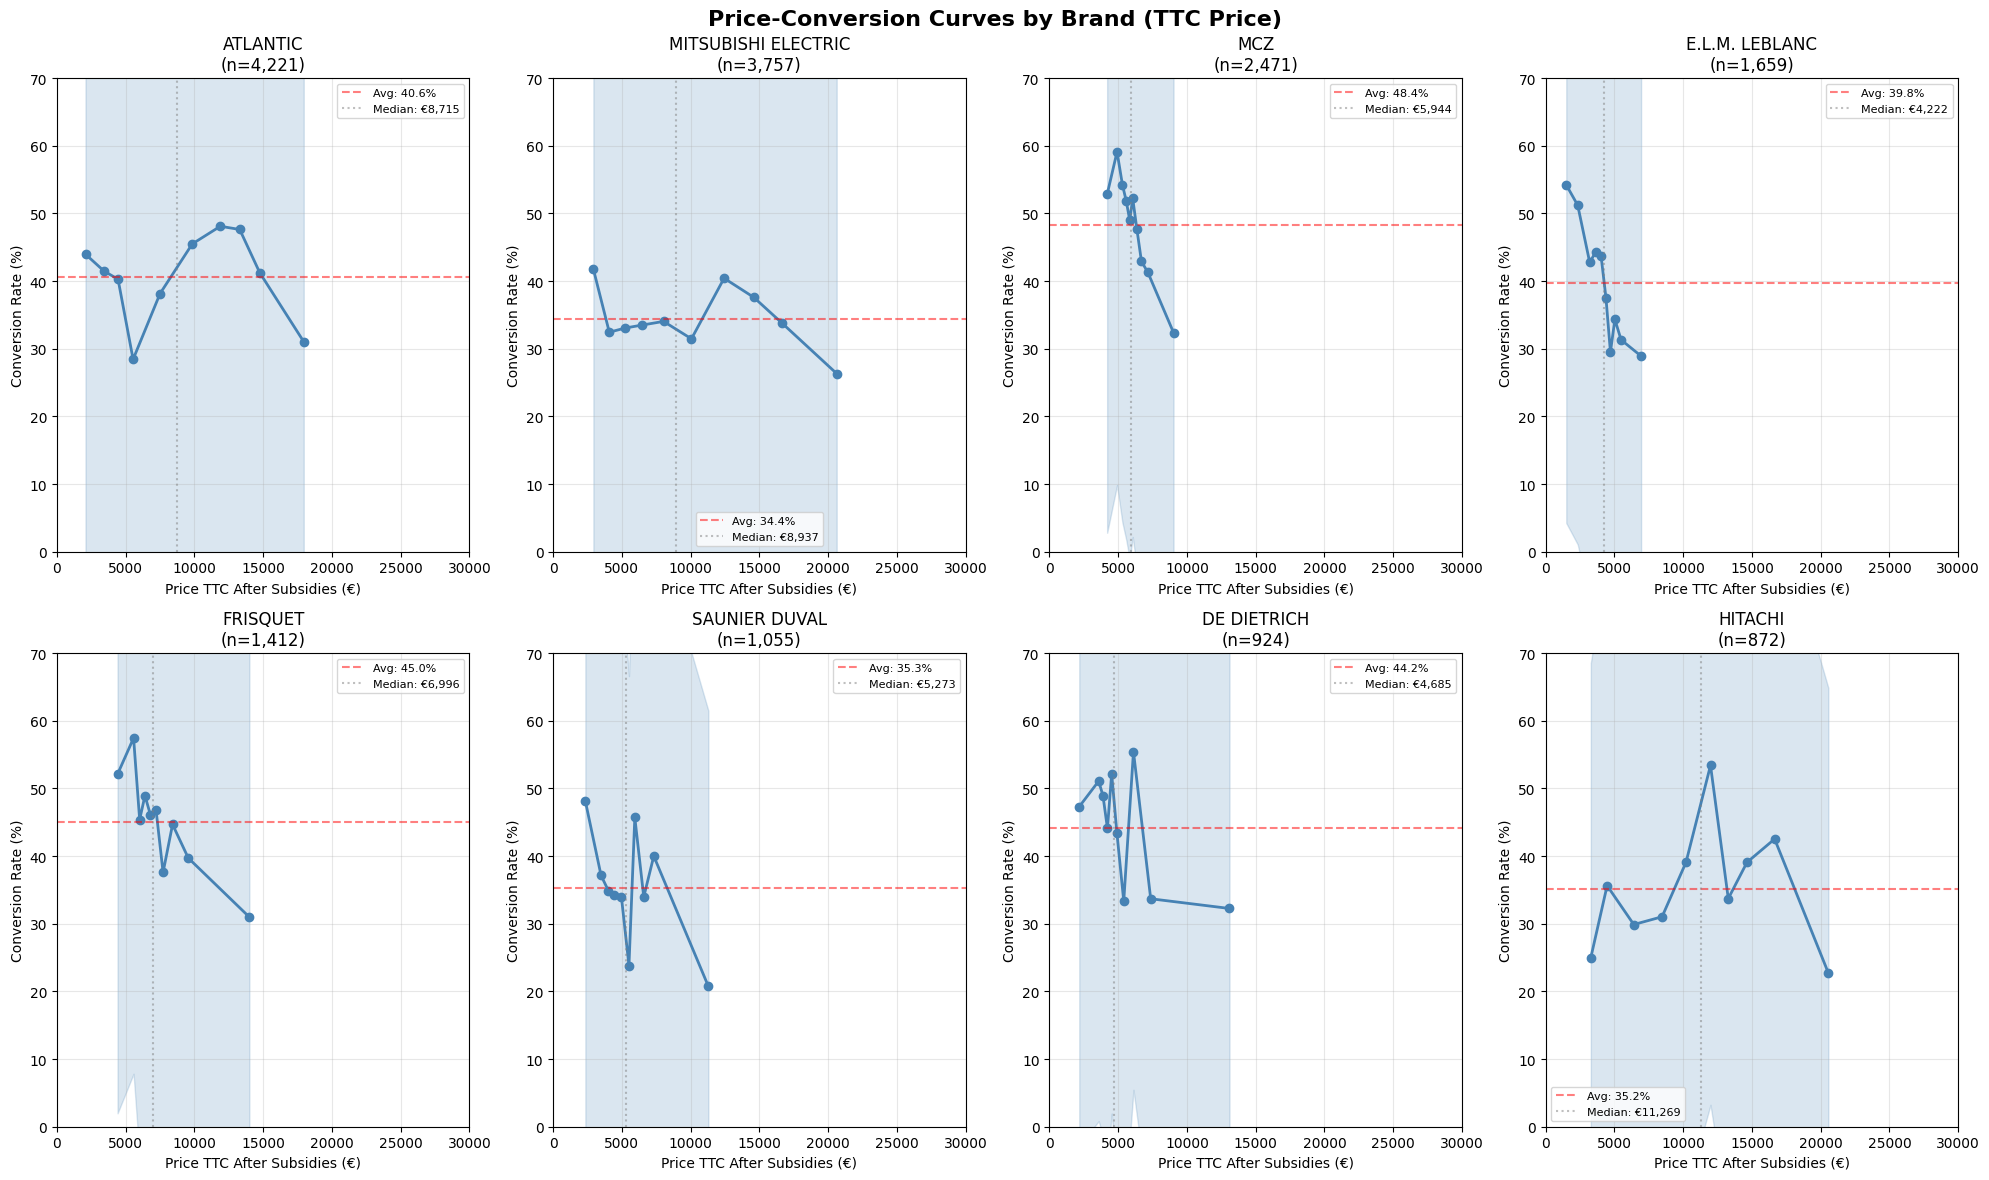

In [8]:
visualise_conversion_by_brand_price(customers, price_var='max_out_of_pocket')

NameError: name 'top_brands' is not defined

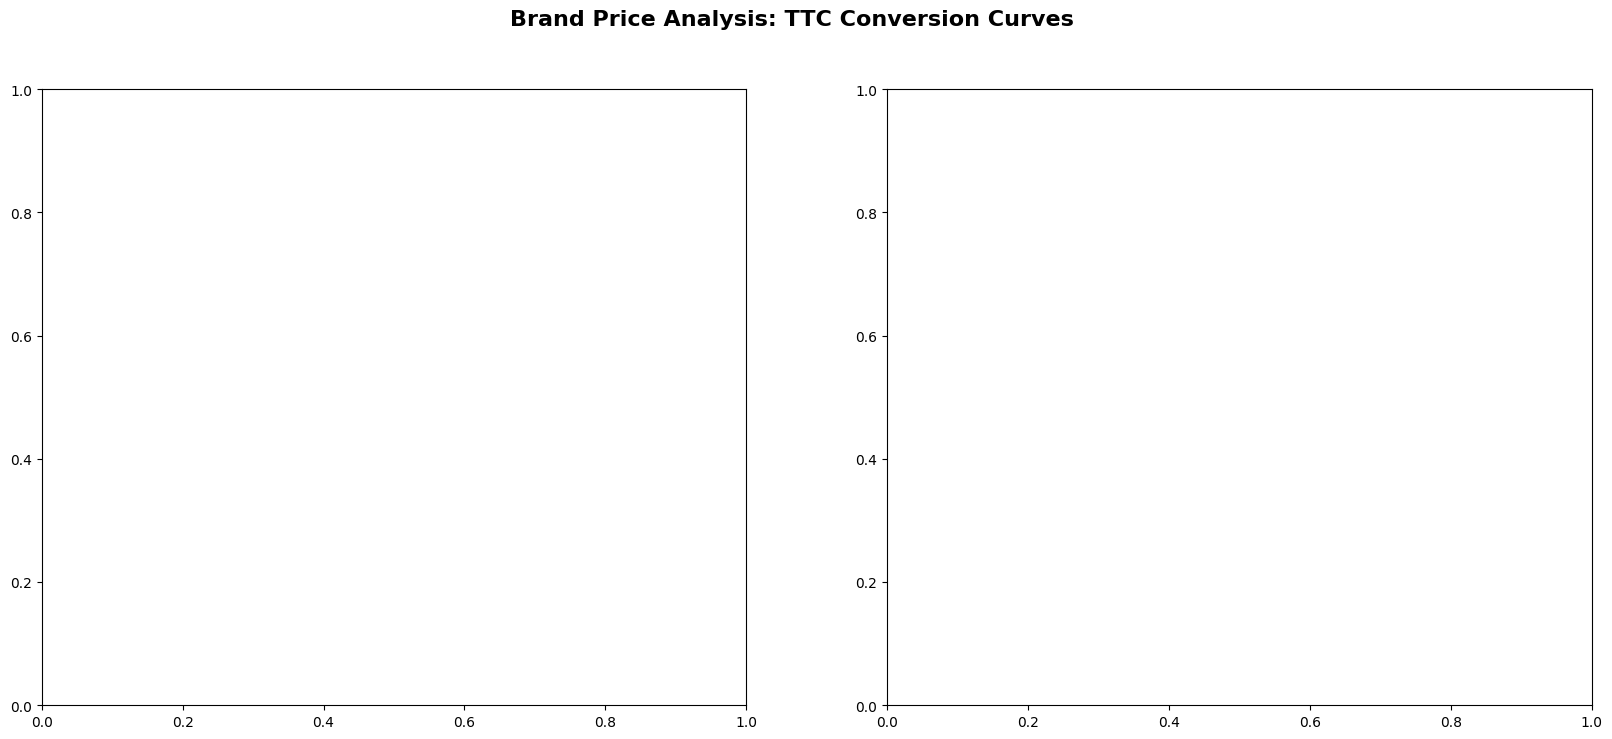

In [10]:
# Create a 2-panel figure: individual curves + summary table
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Brand Price Analysis: TTC Conversion Curves', fontsize=16, fontweight='bold')

# Panel 1: Individual brand curves
ax1 = axes[0]

for idx, (brand, color) in enumerate(zip(top_brands, colors)):
    subset = customers_clean[customers_clean['main_brand'] == brand]
    
    if len(subset) > 200:
        subset['price_bin'] = pd.qcut(subset['avg_out_of_pocket'], q=8, duplicates='drop')
        bin_conv = subset.groupby('price_bin')['converted'].mean() * 100
        bin_price = subset.groupby('price_bin')['avg_out_of_pocket'].mean()
        
        ax1.plot(bin_price, bin_conv, 'o-', color=color, linewidth=2, 
                label=brand, alpha=0.7, markersize=4)

ax1.set_xlabel('Price TTC After Subsidies (€)')
ax1.set_ylabel('Conversion Rate (%)')
ax1.set_title('Brand Price Sensitivity')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', ncol=2, fontsize=8)
ax1.set_xlim(0, 30000)
ax1.set_ylim(0, 70)

# Panel 2: Summary statistics table
ax2 = axes[1]
ax2.axis('off')

# Prepare summary data
summary_data = []
for brand in top_brands:
    subset = customers_clean[customers_clean['main_brand'] == brand]
    if len(subset) > 100:
        # Find best price range
        subset['price_bin'] = pd.qcut(subset['avg_out_of_pocket'], q=5, duplicates='drop')
        bin_stats = subset.groupby('price_bin')['converted'].mean()
        best_bin = bin_stats.idxmax()
        best_conv = bin_stats.max() * 100
        best_price_range = f"€{best_bin.left:,.0f}-{best_bin.right:,.0f}"
        
        summary_data.append([
            brand,
            f"{len(subset):,}",
            f"{subset['converted'].mean()*100:.1f}%",
            f"€{subset['avg_out_of_pocket'].mean():,.0f}",
            best_price_range,
            f"{best_conv:.1f}%"
        ])

# Create table
table = ax2.table(cellText=summary_data,
                  colLabels=['Brand', 'Customers', 'Avg Conv', 'Avg Price', 'Best Price Range', 'Best Conv'],
                  cellLoc='left',
                  loc='center',
                  colWidths=[0.15, 0.1, 0.1, 0.15, 0.25, 0.1])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

# Color code by performance
for i, row in enumerate(summary_data):
    conv = float(row[2].strip('%'))
    if conv > 45:
        table[(i+1, 2)].set_facecolor('lightgreen')
    elif conv < 35:
        table[(i+1, 2)].set_facecolor('lightcoral')

ax2.set_title('Brand Performance Summary', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*80)
print("TTC PRICE-CONVERSION CURVES: 4 EQUIPMENT TYPES, MULTIPLE BRANDS PER GRAPH")
print("="*80)

# Equipment types to analyze
equipment_types = ['Heat Pump', 'Boiler', 'Stove', 'AC']
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('TTC Price-Conversion Curves: One Graph Per Equipment Type', fontsize=16, fontweight='bold')

# Flatten axes for iteration
axes = axes.flatten()

for idx, equipment in enumerate(equipment_types):
    ax = axes[idx]
    
    # Filter for this equipment type
    equip_subset = customers_clean[customers_clean['main_equipment_category'] == equipment]
    
    # Get top brands for this equipment type (minimum 50 customers)
    brand_counts = equip_subset['main_brand'].value_counts()
    top_brands_equip = brand_counts[brand_counts > 50].head(6).index.tolist()
    
    print(f"\n{equipment} - Top brands: {top_brands_equip}")
    
    # Use colormap for brands
    colors = plt.cm.tab10(np.linspace(0, 1, len(top_brands_equip)))
    
    for brand_idx, (brand, color) in enumerate(zip(top_brands_equip, colors)):
        brand_subset = equip_subset[equip_subset['main_brand'] == brand]
        
        if len(brand_subset) > 30:  # Need enough data points
            # Create price bins using TTC out_of_pocket
            try:
                brand_subset['price_bin'] = pd.qcut(brand_subset['avg_out_of_pocket'], q=5, duplicates='drop')
                bin_conv = brand_subset.groupby('price_bin')['converted'].mean() * 100
                bin_price = brand_subset.groupby('price_bin')['avg_out_of_pocket'].mean()
                
                # Plot line for this brand
                ax.plot(bin_price, bin_conv, 'o-', color=color, linewidth=2, 
                        label=f'{brand} (n={len(brand_subset):,})', alpha=0.8, markersize=4)
            except:
                print(f"    Skipping {brand} - insufficient price variation")
    
    # Add average line for this equipment type
    equip_avg = equip_subset['converted'].mean() * 100
    ax.axhline(y=equip_avg, color='black', linestyle='--', linewidth=1,
               label=f'{equipment} avg: {equip_avg:.1f}%', alpha=0.5)
    
    # Labels and formatting
    ax.set_xlabel('TTC Price After Subsidies (€)', fontsize=10)
    ax.set_ylabel('Conversion Rate (%)', fontsize=10)
    ax.set_title(f'{equipment} (n={len(equip_subset):,} customers)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=7)
    ax.set_xlim(0, 25000)
    ax.set_ylim(0, 80)

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Seasonal Effects on Customer Conversion', fontsize=16, fontweight='bold')

# Plot 1: Conversion by month
ax1 = axes[0, 0]
monthly_conv = customers_clean.groupby('month')['converted'].agg(['mean', 'count'])
monthly_conv = monthly_conv.reindex(range(1, 13))  # Ensure all months show

bars = ax1.bar(monthly_conv.index, monthly_conv['mean'] * 100, 
               color='steelblue', alpha=0.7)
ax1.set_xlabel('Month')
ax1.set_ylabel('Customer Conversion Rate (%)')
ax1.set_title('Conversion Rate by Month')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax1.grid(True, alpha=0.3, axis='y')

# Add sample sizes
for i, (month, row) in enumerate(monthly_conv.iterrows()):
    ax1.text(month, row['mean']*100 + 1, f'n={int(row["count"]):,}', 
             ha='center', fontsize=8, rotation=45)

# Plot 2: Conversion by season
ax2 = axes[0, 1]
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
seasonal_conv = customers_clean.groupby('season')['converted'].agg(['mean', 'count'])
seasonal_conv = seasonal_conv.reindex(season_order)

bars = ax2.bar(season_order, seasonal_conv['mean'] * 100, 
               color=['lightblue', 'lightgreen', 'orange', 'brown'], alpha=0.7)
ax2.set_xlabel('Season')
ax2.set_ylabel('Customer Conversion Rate (%)')
ax2.set_title('Conversion Rate by Season')
ax2.grid(True, alpha=0.3, axis='y')

for bar, (season, row) in zip(bars, seasonal_conv.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{row["mean"]*100:.1f}%\nn={int(row["count"]):,}', 
             ha='center', fontweight='bold')

# Plot 3: Product mix by season
ax3 = axes[1, 0]
products = ['Heat Pump', 'Boiler', 'Stove', 'AC']
season_data = []

for season in season_order:
    subset = customers_clean[customers_clean['season'] == season]
    product_shares = []
    for product in products:
        share = (subset['main_equipment_category'] == product).mean() * 100
        product_shares.append(share)
    season_data.append(product_shares)

season_data = np.array(season_data).T

bottom = np.zeros(len(season_order))
for i, (product, shares) in enumerate(zip(products, season_data)):
    ax3.bar(season_order, shares, bottom=bottom, label=product, alpha=0.7)
    bottom += shares

ax3.set_xlabel('Season')
ax3.set_ylabel('Product Mix (%)')
ax3.set_title('Product Mix by Season')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Heat pump conversion by season
ax4 = axes[1, 1]
hp_seasonal = customers_clean[customers_clean['ever_bought_heat_pump']].groupby('season')['converted'].agg(['mean', 'count'])
hp_seasonal = hp_seasonal.reindex(season_order)

bars = ax4.bar(season_order, hp_seasonal['mean'] * 100, 
               color='green', alpha=0.7)
ax4.set_xlabel('Season')
ax4.set_ylabel('Heat Pump Conversion Rate (%)')
ax4.set_title('Heat Pump Conversion by Season')
ax4.grid(True, alpha=0.3, axis='y')

for bar, (season, row) in zip(bars, hp_seasonal.iterrows()):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{row["mean"]*100:.1f}%\nn={int(row["count"]):,}', 
             ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*80)
print("SEASONAL STATISTICS")
print("="*80)

print("\nConversion by season:")
for season in season_order:
    subset = customers_clean[customers_clean['season'] == season]
    print(f"  {season}: {subset['converted'].mean():.1%} (n={len(subset):,})")

# Statistical test for seasonality
from scipy.stats import chi2_contingency
season_contingency = pd.crosstab(customers_clean['season'], customers_clean['converted'])
chi2, p_value, dof, expected = chi2_contingency(season_contingency)
print(f"\nSeasonality chi-square p-value: {p_value:.6f}")
print(f"Statistically significant: {'YES' if p_value < 0.05 else 'NO'}")

In [ ]:
print("\n" + "="*80)
print("POLICY SUSPENSION IMPACT")
print("="*80)

# Compare conversion during vs outside suspensions
susp_conv = customers_clean.groupby('during_suspension')['converted'].agg(['mean', 'count'])
susp_conv.index = ['Normal Periods', 'During Suspension']
print("\nConversion during subsidy suspensions:")
print(susp_conv)

# Statistical test
susp_contingency = pd.crosstab(customers_clean['during_suspension'], customers_clean['converted'])
chi2, p_value, dof, expected = chi2_contingency(susp_contingency)
print(f"\nSuspension impact p-value: {p_value:.6e}")
print(f"Statistically significant: {'YES' if p_value < 0.05 else 'NO'}")

# Check if product mix shifts during suspensions
print("\nProduct mix during suspensions:")
product_mix_susp = pd.crosstab(
    customers_clean['during_suspension'], 
    customers_clean['main_equipment_category'],
    normalize='index'
) * 100
print(product_mix_susp.round(1))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Impact of Subsidy Suspensions on Customer Conversion', fontsize=14, fontweight='bold')

# Plot 1: Conversion comparison
ax1 = axes[0]
bars = ax1.bar(['Normal Periods', 'During Suspension'], 
               [susp_conv.loc['Normal Periods', 'mean'], susp_conv.loc['During Suspension', 'mean']],
               color=['steelblue', 'red'], alpha=0.7)
ax1.set_ylabel('Customer Conversion Rate')
ax1.set_title('Conversion Rate: Normal vs Suspension Periods')
ax1.grid(True, alpha=0.3, axis='y')

for bar, (period, row) in zip(bars, susp_conv.iterrows()):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{row["mean"]:.1%}\nn={int(row["count"]):,}', 
             ha='center', fontweight='bold')

# Plot 2: Heat pump adoption during suspensions
ax2 = axes[1]
hp_susp = customers_clean.groupby('during_suspension')['ever_bought_heat_pump'].mean() * 100
bars = ax2.bar(['Normal Periods', 'During Suspension'], hp_susp.values,
               color=['steelblue', 'red'], alpha=0.7)
ax2.set_ylabel('Heat Pump Adoption (%)')
ax2.set_title('Heat Pump Adoption: Normal vs Suspension')
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, hp_susp.values):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*80)
print("YEAR-OVER-YEAR TRENDS")
print("="*80)

# Group by year and quarter
customers_clean['year_quarter'] = customers_clean['first_quote_date'].dt.to_period('Q')
yearly_trend = customers_clean.groupby('year_quarter')['converted'].agg(['mean', 'count'])

print("\nQuarterly conversion rates:")
print(yearly_trend)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Quarterly trend
ax1 = axes[0]
quarters = [str(q) for q in yearly_trend.index]
values = yearly_trend['mean'] * 100

ax1.plot(quarters, values, 'bo-', linewidth=2, markersize=8)
ax1.fill_between(quarters, values - 2, values + 2, alpha=0.2, color='blue')
ax1.set_xlabel('Year-Quarter')
ax1.set_ylabel('Customer Conversion Rate (%)')
ax1.set_title('Quarterly Conversion Trend')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Volume trend
ax2 = axes[1]
volumes = yearly_trend['count'].values
ax2.bar(quarters, volumes, color='lightcoral', alpha=0.7)
ax2.set_xlabel('Year-Quarter')
ax2.set_ylabel('Number of New Customers')
ax2.set_title('Customer Volume by Quarter')
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*80)
print("REGIONAL SEASONAL PATTERNS")
print("="*80)

# Focus on top regions
top_regions = customers_clean['main_region'].value_counts().head(3).index.tolist()
print(f"\nTop regions: {top_regions}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Seasonal Patterns by Region', fontsize=14, fontweight='bold')

for idx, region in enumerate(top_regions):
    ax = axes[idx]
    subset = customers_clean[customers_clean['main_region'] == region]
    
    seasonal = subset.groupby('season')['converted'].mean() * 100
    seasonal = seasonal.reindex(season_order)
    
    ax.plot(season_order, seasonal.values, 'o-', linewidth=2, markersize=8)
    ax.set_ylim(30, 50)
    ax.set_xlabel('Season')
    ax.set_ylabel('Conversion Rate (%)')
    ax.set_title(f'{region} (n={len(subset):,})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Best and worst months
monthly_stats = customers_clean.groupby('month')['converted'].agg(['mean', 'count'])
best_month = monthly_stats['mean'].idxmax()
worst_month = monthly_stats['mean'].idxmin()
print(f"\nBest month: {best_month} ({monthly_stats.loc[best_month, 'mean']:.1%}, n={monthly_stats.loc[best_month, 'count']:.0f})")
print(f"Worst month: {worst_month} ({monthly_stats.loc[worst_month, 'mean']:.1%}, n={monthly_stats.loc[worst_month, 'count']:.0f})")

# Best and worst seasons
seasonal_stats = customers_clean.groupby('season')['converted'].agg(['mean', 'count'])
best_season = seasonal_stats['mean'].idxmax()
worst_season = seasonal_stats['mean'].idxmin()
print(f"\nBest season: {best_season} ({seasonal_stats.loc[best_season, 'mean']:.1%})")
print(f"Worst season: {worst_season} ({seasonal_stats.loc[worst_season, 'mean']:.1%})")

# Suspension impact
print(f"\nSuspension periods impact: {susp_conv.loc['During Suspension', 'mean']:.1%} vs {susp_conv.loc['Normal Periods', 'mean']:.1%}")
print(f"Difference: {(susp_conv.loc['During Suspension', 'mean'] - susp_conv.loc['Normal Periods', 'mean'])*100:.1f} points")

# Heat pump seasonality
hp_seasonal = customers_clean[customers_clean['ever_bought_heat_pump']].groupby('season')['converted'].mean()
print(f"\nHeat pump conversion by season:")
for season in season_order:
    if season in hp_seasonal.index:
        print(f"  {season}: {hp_seasonal[season]:.1%}")

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Price-Conversion Relationship: How It Has Changed Over Time', fontsize=16, fontweight='bold')

periods = ['2023', '2024', '2025', '2026']
colors = ['green', 'blue', 'orange', 'red']

for idx, (period, color) in enumerate(zip(periods, colors)):
    ax = axes[idx // 2, idx % 2]
    
    subset = customers_clean[customers_clean['period'] == period]
    if len(subset) > 200:
        # Create price bins
        try:
            subset['price_bin'] = pd.qcut(subset['max_out_of_pocket'], q=15, duplicates='drop')
            bin_conv = subset.groupby('price_bin')['converted'].mean()
            bin_price = subset.groupby('price_bin')['max_out_of_pocket'].mean()
            
            ax.plot(bin_price, bin_conv, 'o-', color=color, linewidth=2, markersize=4)
            ax.axhline(y=subset['converted'].mean(), color=color, linestyle='--', 
                      alpha=0.5, label=f'Avg: {subset["converted"].mean():.1%}')
            
            # Highlight heat pump range
            ax.axvspan(12000, 16000, alpha=0.1, color='green', label='Heat pump range')
            
            ax.set_xlabel('Maximum Quote Price (€)')
            ax.set_ylabel('Conversion Rate')
            ax.set_title(f'{period} (n={len(subset):,}, overall conv={subset["converted"].mean():.1%})')
            ax.grid(True, alpha=0.3)
            ax.legend()
            ax.set_ylim(0, 0.7)
        except:
            ax.text(0.5, 0.5, f'Insufficient data for {period}', ha='center', va='center')
            ax.set_title(f'{period} (insufficient data)')

plt.tight_layout()
plt.show()

In [ ]:
# Overlay all years on one plot
fig, ax = plt.subplots(figsize=(14, 8))

for period, color in zip(['2023', '2024', '2025', '2026'], ['green', 'blue', 'orange', 'red']):
    subset = customers_clean[customers_clean['period'] == period]
    if len(subset) > 200:
        # Create price bins
        subset['price_bin'] = pd.qcut(subset['max_out_of_pocket'], q=10, duplicates='drop')
        bin_conv = subset.groupby('price_bin')['converted'].mean()
        bin_price = subset.groupby('price_bin')['max_out_of_pocket'].mean()
        
        ax.plot(bin_price, bin_conv, 'o-', color=color, linewidth=2, 
                label=f'{period} (n={len(subset):,}, conv={subset["converted"].mean():.1%})')

ax.axvspan(12000, 16000, alpha=0.1, color='green', label='Heat pump range')
ax.set_xlabel('Maximum Quote Price (€)')
ax.set_ylabel('Customer Conversion Rate')
ax.set_title('The Conversion Collapse: Price-Response Curves by Year')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
ax.set_ylim(0, 0.7)

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*80)
print("HEAT PUMP PERFORMANCE OVER TIME")
print("="*80)

hp_over_time = customers_clean[customers_clean['ever_bought_heat_pump']].groupby('period').agg({
    'converted': ['mean', 'count'],
    'max_out_of_pocket': 'mean',
    'had_subsidy_issue': 'mean'
}).round(3)

hp_over_time.columns = ['conversion_rate', 'customer_count', 'avg_price', 'subsidy_issue_rate']
print("\nHeat pump customers by year:")
print(hp_over_time)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Heat Pump Performance During the Crisis', fontsize=14, fontweight='bold')

# Plot 1: Heat pump conversion vs overall
ax1 = axes[0]
overall_conv = customers_clean.groupby('period')['converted'].mean() * 100
hp_conv = customers_clean[customers_clean['ever_bought_heat_pump'].fillna(False)].groupby('period')['converted'].mean() * 100

x = range(len(overall_conv))
width = 0.35
ax1.bar([i - width/2 for i in x], overall_conv.values, width, label='Overall', color='gray', alpha=0.7)
ax1.bar([i + width/2 for i in x], hp_conv.values, width, label='Heat Pump', color='green', alpha=0.7)
ax1.set_xticks(x)
ax1.set_xticklabels(overall_conv.index)
ax1.set_ylabel('Conversion Rate (%)')
ax1.set_title('Heat Pump vs Overall Conversion')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Heat pump volume trend
ax2 = axes[1]
hp_volume = customers_clean[customers_clean['ever_bought_heat_pump'].fillna(False)].groupby('period').size()
total_volume = customers_clean.groupby('period').size()
hp_share = (hp_volume / total_volume * 100).fillna(0)

ax2.plot(hp_share.index, hp_share.values, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Year')
ax2.set_ylabel('Heat Pump Share of Customers (%)')
ax2.set_title('Heat Pump Adoption Trend')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*80)
print("SWEET SPOT ANALYSIS OVER TIME")
print("="*80)

# Function to identify sweet spots
def find_sweet_spots(df, year, n_bins=20):
    subset = df[df['period'] == year].copy()
    if len(subset) < 500:
        return None
    
    subset['price_bin'] = pd.qcut(subset['max_out_of_pocket'], q=n_bins, duplicates='drop')
    bin_stats = subset.groupby('price_bin').agg({
        'converted': ['mean', 'count'],
        'max_out_of_pocket': 'mean'
    })
    bin_stats.columns = ['conv_rate', 'count', 'price']
    bin_stats = bin_stats.reset_index()
    
    overall_avg = subset['converted'].mean()
    sweet_spots = bin_stats[bin_stats['conv_rate'] > overall_avg + 0.03].copy()  # 3 points above avg
    
    return sweet_spots

print("\nSweet spots by year (price points with conversion > avg + 3%):")
for year in ['2023', '2024', '2025']:
    sweet = find_sweet_spots(customers_clean, year)
    if sweet is not None and len(sweet) > 0:
        print(f"\n{year} (overall avg: {customers_clean[customers_clean['period']==year]['converted'].mean():.1%}):")
        for _, row in sweet.iterrows():
            print(f"  €{row['price']:,.0f}: {row['conv_rate']:.1%} (n={row['count']:.0f})")

# Visualization of shifting sweet spots
fig, ax = plt.subplots(figsize=(14, 8))

for year, color in zip(['2023', '2024', '2025'], ['green', 'blue', 'orange']):
    subset = customers_clean[customers_clean['period'] == year].copy()
    if len(subset) > 500:
        subset['price_bin'] = pd.qcut(subset['max_out_of_pocket'], q=20, duplicates='drop')
        bin_stats = subset.groupby('price_bin').agg({
            'converted': 'mean',
            'max_out_of_pocket': 'mean'
        }).reset_index(drop=True)
        
        # Smooth for better visualization
        from scipy.ndimage import gaussian_filter1d
        smoothed = gaussian_filter1d(bin_stats['converted'].values, sigma=1)
        
        ax.plot(bin_stats['max_out_of_pocket'], smoothed, color=color, linewidth=2, 
                label=f'{year} (avg: {subset["converted"].mean():.1%})')
        
        # Mark the peak
        peak_idx = smoothed.argmax()
        peak_price = bin_stats['max_out_of_pocket'].iloc[peak_idx]
        peak_conv = smoothed[peak_idx]
        ax.plot(peak_price, peak_conv, 'o', color=color, markersize=8)
        ax.text(peak_price, peak_conv + 0.02, f'€{peak_price:,.0f}\n{peak_conv:.1%}', 
                ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Maximum Quote Price (€)')
ax.set_ylabel('Conversion Rate (smoothed)')
ax.set_title('Sweet Spots Are Shifting: Where Should You Focus?')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*80)
print("ADMINISTRATIVE UNCERTAINTY EFFECT")
print("="*80)

# First, ensure we have the right variables
# We need to calculate processing time and uncertainty metrics at customer level

# If we have quote-level data with dates, we can calculate:
# 1. Time from first quote to conversion (decision time)
# 2. Time from conversion to signature (if available)
# 3. Number of quotes per customer (engagement)
# 4. Price volatility (changes between quotes)

# Let's add these to our customer dataset if not already present

In [ ]:
print("\n" + "="*80)
print("ADMINISTRATIVE UNCERTAINTY EFFECT (continued)")
print("="*80)

# First, let's examine the decision time distribution
print("\nDecision time distribution:")
print(customers_clean['decision_days'].describe())

# Check how many have 1-day decisions
one_day_count = (customers_clean['decision_days'] == 1).sum()
print(f"\nCustomers with 1-day decision: {one_day_count:,} ({one_day_count/len(customers_clean):.1%})")

# Fix: Create custom bins instead of quantile bins
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Administrative Uncertainty: Does Decision Time Matter?', fontsize=16, fontweight='bold')

# Plot 1: Conversion by decision time bins (custom bins)
ax1 = axes[0, 0]
# Create meaningful time bins
bins = [0, 1, 7, 30, 90, 365]
labels = ['Same day (1)', 'Quick (2-7 days)', 'Medium (8-30 days)', 'Slow (31-90 days)', 'Very Slow (>90 days)']

customers_clean['time_bin'] = pd.cut(customers_clean['decision_days'], bins=bins, labels=labels)

time_conv = customers_clean.groupby('time_bin')['converted'].mean() * 100
time_counts = customers_clean.groupby('time_bin').size()

bars = ax1.bar(range(len(time_conv)), time_conv.values, color='steelblue', alpha=0.7)
ax1.set_xticks(range(len(time_conv)))
ax1.set_xticklabels(time_conv.index, rotation=45, ha='right')
ax1.set_ylabel('Conversion Rate (%)')
ax1.set_title('Conversion by Decision Time')
ax1.grid(True, alpha=0.3, axis='y')

for i, (bar, (idx, count)) in enumerate(zip(bars, time_counts.items())):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%\nn={count:,}', ha='center', fontsize=9)

# Plot 2: Decision time by year (is it getting longer?)
ax2 = axes[0, 1]
yearly_time = customers_clean.groupby('period')['decision_days'].median()
ax2.plot(yearly_time.index, yearly_time.values, 'bo-', linewidth=2, markersize=8)
ax2.set_xlabel('Year')
ax2.set_ylabel('Median Decision Time (days)')
ax2.set_title('Decision Time Getting Longer?')
ax2.grid(True, alpha=0.3)

# Plot 3: Price volatility by conversion status
ax3 = axes[1, 0]
conv_cv = customers_clean[customers_clean['converted']==1]['price_cv'].dropna()
nonconv_cv = customers_clean[customers_clean['converted']==0]['price_cv'].dropna()

ax3.boxplot([nonconv_cv, conv_cv], labels=['Not Converted', 'Converted'])
ax3.set_ylabel('Price Volatility (CV)')
ax3.set_title('Price Volatility: Converted vs Not Converted')
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Quote count by conversion status
ax4 = axes[1, 1]
conv_quotes = customers_clean[customers_clean['converted']==1]['quote_count']
nonconv_quotes = customers_clean[customers_clean['converted']==0]['quote_count']

ax4.boxplot([nonconv_quotes, conv_quotes], labels=['Not Converted', 'Converted'])
ax4.set_ylabel('Number of Quotes')
ax4.set_title('Quote Count: Converted vs Not Converted')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# Create the definitive administrative burden visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('The Real Story: 84% Decide in 1 Day', fontsize=16, fontweight='bold')

# Plot 1: The 1-day dominance
# Plot 1: The 1-day dominance (DYNAMIC with error handling)
ax1 = axes[0, 0]

# Calculate dynamically from data with safe fallbacks
if 'decision_days' in customers_clean.columns:
    same_day_count = (customers_clean['decision_days'] == 1).sum()
    longer_count = (customers_clean['decision_days'] > 1).sum()
    total_customers = len(customers_clean)
    
    same_day_pct = (same_day_count / total_customers) * 100
    longer_pct = (longer_count / total_customers) * 100
    
    labels = [f'Same Day Decision\n({same_day_count:,} customers)', 
              f'Longer Process\n({longer_count:,} customers)']
    sizes = [same_day_pct, longer_pct]
    
    # Only create pie chart if we have valid data
    if total_customers > 0 and same_day_pct + longer_pct > 99:
        colors = ['green', 'orange']
        explode = (0.1, 0)
        
        wedges, texts, autotexts = ax1.pie(
            sizes, 
            explode=explode, 
            labels=labels, 
            colors=colors, 
            autopct=lambda pct: f'{pct:.0f}%\n({int(pct*total_customers/100):,})',
            shadow=True, 
            startangle=90
        )
        
        # Make the percentage text bold
        for autotext in autotexts:
            autotext.set_fontweight('bold')
        
        ax1.set_title(f'{same_day_pct:.0f}% of Customers Decide in 1 Day', fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'No decision_days data available', 
             ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title('Decision Time Analysis (Data Missing)')

# Plot 2: Conversion by decision time
ax2 = axes[0, 1]
time_bins = ['Same Day', '2-7 days', '8-30 days', '31-90 days', '>90 days']
conv_by_time = [
    customers_clean[customers_clean['decision_days']==1]['converted'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>1) & (customers_clean['decision_days']<=7)]['converted'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>7) & (customers_clean['decision_days']<=30)]['converted'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>30) & (customers_clean['decision_days']<=90)]['converted'].mean() * 100,
    customers_clean[customers_clean['decision_days']>90]['converted'].mean() * 100
]
bars = ax2.bar(time_bins, conv_by_time, color=['green', 'yellowgreen', 'orange', 'red', 'darkred'])
ax2.set_ylabel('Conversion Rate (%)')
ax2.set_title('Longer Process = Higher Conversion?')
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, conv_by_time):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{val:.1f}%', ha='center')

# Plot 3: Heat pump share by decision time
ax3 = axes[1, 0]
hp_share = [
    customers_clean[customers_clean['decision_days']==1]['ever_bought_heat_pump'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>1) & (customers_clean['decision_days']<=7)]['ever_bought_heat_pump'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>7) & (customers_clean['decision_days']<=30)]['ever_bought_heat_pump'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>30) & (customers_clean['decision_days']<=90)]['ever_bought_heat_pump'].mean() * 100,
    customers_clean[customers_clean['decision_days']>90]['ever_bought_heat_pump'].mean() * 100
]
ax3.plot(time_bins, hp_share, 'go-', linewidth=2, markersize=8)
ax3.set_ylabel('Heat Pump Share (%)')
ax3.set_title('Heat Pumps Dominate Long Sales Cycles')
ax3.grid(True, alpha=0.3)

# Plot 4: Subsidy issues by decision time
ax4 = axes[1, 1]
subsidy_share = [
    customers_clean[customers_clean['decision_days']==1]['had_subsidy_issue'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>1) & (customers_clean['decision_days']<=7)]['had_subsidy_issue'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>7) & (customers_clean['decision_days']<=30)]['had_subsidy_issue'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>30) & (customers_clean['decision_days']<=90)]['had_subsidy_issue'].mean() * 100,
    customers_clean[customers_clean['decision_days']>90]['had_subsidy_issue'].mean() * 100
]
ax4.bar(time_bins, subsidy_share, color='purple', alpha=0.7)
ax4.set_ylabel('Subsidy Issue Rate (%)')
ax4.set_title('Long Cycles = Subsidy Complexity')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Create the master price-conversion dashboard
fig = plt.figure(figsize=(20, 16))
fig.suptitle('PRICE-CONVERSION DEPENDENCY DASHBOARD', fontsize=20, fontweight='bold', y=0.98)

# Grid specification
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# ============================================================================
# PLOT 1: Main Price-Conversion Curve with Confidence Intervals
# ============================================================================
ax1 = fig.add_subplot(gs[0, :2])

# Create price bins
price_var = 'max_out_of_pocket'
customers_clean['price_bin'] = pd.qcut(customers_clean[price_var], q=30, duplicates='drop')

binned_stats = customers_clean.groupby('price_bin').agg({
    'converted': ['mean', 'count', 'sem'],
    price_var: 'mean'
}).round(4)

binned_stats.columns = ['conversion_rate', 'customer_count', 'std_error', 'avg_price']
binned_stats['ci_lower'] = binned_stats['conversion_rate'] - 1.96 * binned_stats['std_error']
binned_stats['ci_upper'] = binned_stats['conversion_rate'] + 1.96 * binned_stats['std_error']
binned_stats = binned_stats.reset_index()

# Main curve
ax1.plot(binned_stats['avg_price'], binned_stats['conversion_rate'] * 100, 
         'b-', linewidth=3, label='Conversion rate')

# Confidence interval
ax1.fill_between(binned_stats['avg_price'], 
                 binned_stats['ci_lower'] * 100, 
                 binned_stats['ci_upper'] * 100, 
                 alpha=0.2, color='blue', label='95% CI')

# Overall average
overall_conv = customers_clean['converted'].mean() * 100
ax1.axhline(y=overall_conv, color='red', linestyle='--', linewidth=2, 
            label=f'Overall avg: {overall_conv:.1f}%')

# Highlight sweet spots
# Use price quantiles to define regions
q20 = customers_clean['max_out_of_pocket'].quantile(0.20)
q40 = customers_clean['max_out_of_pocket'].quantile(0.40)
q60 = customers_clean['max_out_of_pocket'].quantile(0.60)
q80 = customers_clean['max_out_of_pocket'].quantile(0.80)

# Define regions based on conversion patterns
ax1.axvspan(0, q20, alpha=0.2, color='green', label=f'Entry level (0-€{q20:,.0f})')
ax1.axvspan(q20, q60, alpha=0.2, color='yellow', label=f'Mid-range (€{q20:,.0f}-{q60:,.0f})')
ax1.axvspan(q60, q80, alpha=0.2, color='orange', label=f'Premium (€{q60:,.0f}-{q80:,.0f})')
ax1.axvspan(q80, customers_clean['max_out_of_pocket'].max(), alpha=0.2, color='gold', 
            label=f'Luxury (€{q80:,.0f}+)')

ax1.set_xlabel('Price (€)', fontsize=12)
ax1.set_ylabel('Customer Conversion Rate (%)', fontsize=12)
ax1.set_title('1. Price-Conversion Curve with 95% Confidence Intervals', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')
ax1.set_xlim(0, 30000)
ax1.set_ylim(20, 60)

# ============================================================================
# PLOT 2: Price Distribution by Conversion Status
# ============================================================================
ax2 = fig.add_subplot(gs[0, 2])

converted_prices = customers_clean[customers_clean['converted']==1]['max_out_of_pocket']
nonconverted_prices = customers_clean[customers_clean['converted']==0]['max_out_of_pocket']

ax2.hist([converted_prices, nonconverted_prices], bins=50, density=True, 
         alpha=0.6, label=['Converted', 'Not Converted'], color=['green', 'red'])
ax2.set_xlabel('Price (€)')
ax2.set_ylabel('Density')
ax2.set_title('2. Price Distribution: Converted vs Not Converted')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 30000)

# ============================================================================
# PLOT 3: Violin Plot - Price by Conversion
# ============================================================================
ax3 = fig.add_subplot(gs[0, 3])

data_to_plot = [nonconverted_prices, converted_prices]
parts = ax3.violinplot(data_to_plot, positions=[0, 1], 
                        showmedians=True, showextrema=True)
parts['bodies'][0].set_facecolor('red')
parts['bodies'][0].set_alpha(0.5)
parts['bodies'][1].set_facecolor('green')
parts['bodies'][1].set_alpha(0.5)
ax3.set_xticks([0, 1])
ax3.set_xticklabels(['Not Converted', 'Converted'])
ax3.set_ylabel('Price (€)')
ax3.set_title('3. Price Distribution by Conversion Status')
ax3.grid(True, alpha=0.3, axis='y')

# ============================================================================
# PLOT 4: Price-Conversion by Product Category
# ============================================================================
ax4 = fig.add_subplot(gs[1, 0])

products = ['Stove', 'Heat Pump', 'Boiler', 'AC']
colors = ['purple', 'green', 'blue', 'orange']

for product, color in zip(products, colors):
    subset = customers_clean[customers_clean['main_equipment_category'] == product]
    if len(subset) > 200:
        subset['price_bin'] = pd.qcut(subset['max_out_of_pocket'], q=15, duplicates='drop')
        bin_conv = subset.groupby('price_bin')['converted'].mean() * 100
        bin_price = subset.groupby('price_bin')['max_out_of_pocket'].mean()
        ax4.plot(bin_price, bin_conv, 'o-', color=color, linewidth=2, 
                label=f'{product} (n={len(subset):,})')

ax4.set_xlabel('Price (€)')
ax4.set_ylabel('Conversion Rate (%)')
ax4.set_title('4. Price-Conversion by Product Category')
ax4.grid(True, alpha=0.3)
ax4.legend()
ax4.set_xlim(0, 30000)

# ============================================================================
# PLOT 5: Heatmap - Conversion by Price and Product
# ============================================================================
ax5 = fig.add_subplot(gs[1, 1])

price_bins = pd.cut(customers_clean['max_out_of_pocket'], bins=8)
product_bins = customers_clean['main_equipment_category']

pivot_table = customers_clean.pivot_table(
    values='converted', 
    index=product_bins, 
    columns=price_bins,
    aggfunc='mean'
) * 100

im = ax5.imshow(pivot_table, cmap='RdYlGn', aspect='auto', vmin=20, vmax=55)
ax5.set_yticks(range(len(pivot_table.index)))
ax5.set_yticklabels(pivot_table.index)
ax5.set_xticks(range(len(pivot_table.columns)))
ax5.set_xticklabels([f'€{int(b.left):,}' for b in pivot_table.columns], rotation=45, ha='right')
ax5.set_title('5. Conversion Heatmap: Price × Product')
plt.colorbar(im, ax=ax5, label='Conversion %')

# ============================================================================
# PLOT 6: Price Sensitivity by Product (Bar Chart)
# ============================================================================
ax6 = fig.add_subplot(gs[1, 2])

sensitivity_data = []
for product in products:
    subset = customers_clean[customers_clean['main_equipment_category'] == product]
    if len(subset) > 200:
        low_price = subset['max_out_of_pocket'] <= subset['max_out_of_pocket'].quantile(0.25)
        high_price = subset['max_out_of_pocket'] >= subset['max_out_of_pocket'].quantile(0.75)
        low_conv = subset[low_price]['converted'].mean() * 100
        high_conv = subset[high_price]['converted'].mean() * 100
        sensitivity_data.append({
            'product': product,
            'low_conv': low_conv,
            'high_conv': high_conv,
            'drop': low_conv - high_conv
        })

sensitivity_df = pd.DataFrame(sensitivity_data)
sensitivity_df = sensitivity_df.sort_values('drop', ascending=True)

x = range(len(sensitivity_df))
width = 0.35
ax6.bar([i - width/2 for i in x], sensitivity_df['low_conv'], width, label='Low Price', color='green', alpha=0.7)
ax6.bar([i + width/2 for i in x], sensitivity_df['high_conv'], width, label='High Price', color='red', alpha=0.7)
ax6.set_xticks(x)
ax6.set_xticklabels(sensitivity_df['product'])
ax6.set_ylabel('Conversion Rate (%)')
ax6.set_title('6. Price Sensitivity: Low vs High Price')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

# ============================================================================
# PLOT 7: Price-Conversion Over Time (Yearly)
# ============================================================================
ax7 = fig.add_subplot(gs[1, 3])

years = ['2023', '2024', '2025']
colors_year = ['green', 'blue', 'red']

for year, color in zip(years, colors_year):
    subset = customers_clean[customers_clean['period'] == year]
    if len(subset) > 500:
        subset['price_bin'] = pd.qcut(subset['max_out_of_pocket'], q=10, duplicates='drop')
        bin_conv = subset.groupby('price_bin')['converted'].mean() * 100
        bin_price = subset.groupby('price_bin')['max_out_of_pocket'].mean()
        ax7.plot(bin_price, bin_conv, 'o-', color=color, linewidth=2, 
                label=f'{year} (avg: {subset["converted"].mean()*100:.1f}%)')

ax7.set_xlabel('Price (€)')
ax7.set_ylabel('Conversion Rate (%)')
ax7.set_title('7. Price-Conversion Curve Over Time')
ax7.grid(True, alpha=0.3)
ax7.legend()
ax7.set_xlim(0, 30000)

# ============================================================================
# PLOT 8: 2D Density Plot - Price vs Conversion (Jittered)
# ============================================================================
ax8 = fig.add_subplot(gs[2, 0])

# Add jitter to conversion for density plot
jitter = np.random.normal(0, 0.02, size=len(customers_clean))
y_jittered = customers_clean['converted'] + jitter

# Create 2D histogram
hb = ax8.hexbin(customers_clean['max_out_of_pocket'], y_jittered, 
                gridsize=40, cmap='YlOrRd', mincnt=1)
ax8.set_xlabel('Price (€)')
ax8.set_ylabel('Conversion (jittered)')
ax8.set_title('8. Density: Where Are the Customers?')
plt.colorbar(hb, ax=ax8, label='Number of customers')
ax8.set_xlim(0, 30000)

# ============================================================================
# PLOT 9: Conversion by Price Decile
# ============================================================================
ax9 = fig.add_subplot(gs[2, 1])

customers_clean['decile'] = pd.qcut(customers_clean['max_out_of_pocket'], q=10, labels=[f'D{i}' for i in range(1, 11)])
decile_conv = customers_clean.groupby('decile')['converted'].mean() * 100
decile_price = customers_clean.groupby('decile')['max_out_of_pocket'].mean()

bars = ax9.bar(range(10), decile_conv.values, color=plt.cm.RdYlGn(decile_conv.values/100))
ax9.set_xticks(range(10))
ax9.set_xticklabels([f'€{int(p):,}' for p in decile_price.values], rotation=45, ha='right')
ax9.set_ylabel('Conversion Rate (%)')
ax9.set_title('9. Conversion by Price Decile')
ax9.grid(True, alpha=0.3, axis='y')

for i, (bar, val) in enumerate(zip(bars, decile_conv.values)):
    ax9.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f'{val:.1f}%', ha='center', fontsize=8)

# ============================================================================
# PLOT 10: Subsidy Issues by Price
# ============================================================================
ax10 = fig.add_subplot(gs[2, 2])

# Create bins for subsidy issue rate
subsidy_by_price = customers_clean.groupby('price_bin').agg({
    'had_subsidy_issue': 'mean',
    'max_out_of_pocket': 'mean'
}).reset_index()

ax10.plot(subsidy_by_price['max_out_of_pocket'], subsidy_by_price['had_subsidy_issue'] * 100, 
          'ro-', linewidth=2, markersize=4)
ax10.set_xlabel('Price (€)')
ax10.set_ylabel('Subsidy Issue Rate (%)')
ax10.set_title('10. Subsidy Issues Increase with Price')
ax10.grid(True, alpha=0.3)
ax10.set_xlim(0, 30000)

# ============================================================================
# PLOT 11: Heat Pump Share by Price
# ============================================================================
ax11 = fig.add_subplot(gs[2, 3])

hp_share = customers_clean.groupby('price_bin')['ever_bought_heat_pump'].mean() * 100
ax11.fill_between(binned_stats['avg_price'], 0, hp_share.values, alpha=0.5, color='green')
ax11.plot(binned_stats['avg_price'], hp_share.values, 'g-', linewidth=2)
ax11.set_xlabel('Price (€)')
ax11.set_ylabel('Heat Pump Share (%)')
ax11.set_title('11. Heat Pumps Dominate High End')
ax11.grid(True, alpha=0.3)
ax11.set_xlim(0, 30000)
ax11.set_ylim(0, 100)

# ============================================================================
# DYNAMIC INSIGHTS CALCULATION
# ============================================================================

# 1. Find top 2 sweet spots (highest converting price bins)
top_bins = binned_stats.nlargest(2, 'conversion_rate')
sweet1_price = top_bins.iloc[0]['avg_price'] / 1000
sweet1_conv = top_bins.iloc[0]['conversion_rate'] * 100
sweet2_price = top_bins.iloc[1]['avg_price'] / 1000
sweet2_conv = top_bins.iloc[1]['conversion_rate'] * 100

# 2. Find dead zone (lowest converting bin)
worst_bin = binned_stats.nsmallest(1, 'conversion_rate').iloc[0]
dead_low = worst_bin['price_bin'].left / 1000
dead_high = worst_bin['price_bin'].right / 1000
dead_conv_low = worst_bin['conversion_rate'] * 100
dead_conv_high = binned_stats['conversion_rate'].quantile(0.25) * 100

# 3. Heat pump metrics
hp_customers = customers_clean[customers_clean['ever_bought_heat_pump'] == True]
hp_subsidy = hp_customers['had_subsidy_issue'].mean() * 100
hp_conv = hp_customers['converted'].mean() * 100

# 4. Price sensitivity from the sensitivity dataframe
sensitivity_str = " > ".join([
    f"{row['product']} ({row['drop']:.1f}pts)" 
    for _, row in sensitivity_df.sort_values('drop', ascending=False).iterrows()
])

# 5. Decision time
same_day_pct = (customers_clean['decision_days'] == 1).mean() * 100

# ============================================================================
# Add dynamic summary annotations
# ============================================================================
fig.text(0.02, 0.02, 
         f"Key Insights:\n"
         f"• Two sweet spots: €{sweet1_price:.1f}k ({sweet1_conv:.1f}%) and €{sweet2_price:.1f}k ({sweet2_conv:.1f}%)\n"
         f"• Dead zone: €{dead_low:.1f}k-{dead_high:.1f}k ({dead_conv_low:.0f}-{dead_conv_high:.0f}%)\n"
         f"• Heat pumps: {hp_subsidy:.0f}% subsidy issues, {hp_conv:.1f}% conversion\n"
         f"• Price sensitivity: {sensitivity_str}\n"
         f"• {same_day_pct:.0f}% decide in 1 day - price is not the only factor",
         fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Print dynamic values for verification
print("\n" + "="*80)
print("DYNAMIC INSIGHTS CALCULATED:")
print("="*80)
print(f"Sweet spots: €{sweet1_price:.1f}k ({sweet1_conv:.1f}%) and €{sweet2_price:.1f}k ({sweet2_conv:.1f}%)")
print(f"Dead zone: €{dead_low:.1f}k-{dead_high:.1f}k ({dead_conv_low:.0f}-{dead_conv_high:.0f}%)")
print(f"Heat pumps: {hp_subsidy:.0f}% subsidy issues, {hp_conv:.1f}% conversion")
print(f"Price sensitivity: {sensitivity_str}")
print(f"Same day decisions: {same_day_pct:.0f}%")

plt.tight_layout()
plt.savefig('price_conversion_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("\n" + "="*80)
print("SIMPLE HEATMAP TEST")
print("="*80)

try:
    # Create simple price bins
    customers['price_bin_simple'] = pd.qcut(customers['max_out_of_pocket'], q=5, duplicates='drop')
    
    # Create simple product bins (if available)
    if 'main_equipment_category' in customers.columns:
        # Create pivot
        simple_pivot = customers.pivot_table(
            values='converted',
            index='main_equipment_category',
            columns='price_bin_simple',
            aggfunc='mean'
        ) * 100
        
        print("Simple pivot table:")
        print(simple_pivot)
        
        # Plot
        fig, ax = plt.subplots(figsize=(10, 6))
        im = ax.imshow(simple_pivot, cmap='RdYlGn', aspect='auto')
        ax.set_yticks(range(len(simple_pivot.index)))
        ax.set_yticklabels(simple_pivot.index)
        ax.set_xticks(range(len(simple_pivot.columns)))
        ax.set_xticklabels([f'{int(b.left):,}-{int(b.right):,}' for b in simple_pivot.columns], rotation=45)
        plt.colorbar(im, ax=ax)
        plt.title('Simple Price-Conversion Heatmap')
        plt.tight_layout()
        plt.show()
    else:
        print("No product category column found")
        
except Exception as e:
    print(f"Error in simple heatmap: {e}")

# Check if LBC might be in main_product_family
if 'main_product_family' in customers.columns:
    print("\n" + "="*80)
    print("CHECKING MAIN PRODUCT FAMILY")
    print("="*80)
    print(customers['main_product_family'].value_counts().head(20))

In [ ]:
# Create Product/Brand Heatmap (Product Type as rows, Brand as columns)
fig, axes = plt.subplots(1, 2, figsize=(22, 10))
fig.suptitle('Product vs Brand Analysis (Product Types × Brands)', fontsize=16, fontweight='bold')

# ============================================================================
# HEAT MAP 1: Volume (Number of Customers) by Product and Brand
# ============================================================================
ax1 = axes[0]

# Get top brands and product categories
top_brands = customers['main_brand'].value_counts().head(12).index.tolist()
product_cats = ['Heat Pump', 'Boiler', 'Stove', 'AC', 'Other']

# Create a crosstab of product vs brand (counts)
product_brand_counts = pd.crosstab(
    customers['main_equipment_category'], 
    customers['main_brand']
)

# Filter to top brands only
product_brand_counts = product_brand_counts[top_brands]

# Create heatmap (rows = products, columns = brands)
im1 = ax1.imshow(product_brand_counts, cmap='YlOrRd', aspect='auto')
ax1.set_yticks(range(len(product_cats)))
ax1.set_yticklabels(product_cats)
ax1.set_xticks(range(len(top_brands)))
ax1.set_xticklabels(top_brands, rotation=45, ha='right')
ax1.set_xlabel('Brand')
ax1.set_ylabel('Product Type')
ax1.set_title('Customer Volume: Number of Customers by Product and Brand')

# Add colorbar
plt.colorbar(im1, ax=ax1, label='Number of Customers')

# Add value annotations
for i in range(len(product_cats)):
    for j in range(len(top_brands)):
        value = product_brand_counts.iloc[i, j]
        if value > 50:  # Only show larger values
            color = 'white' if value > 500 else 'black'
            ax1.text(j, i, f'{value}', ha='center', va='center', color=color, fontweight='bold')

# ============================================================================
# HEAT MAP 2: Conversion Rate by Product and Brand
# ============================================================================
ax2 = axes[1]

# Create pivot table of conversion rate by product and brand
product_brand_conv = customers.pivot_table(
    values='converted',
    index='main_equipment_category',
    columns='main_brand',
    aggfunc='mean'
) * 100

# Filter to top brands only
product_brand_conv = product_brand_conv[top_brands]

# Create heatmap (rows = products, columns = brands)
im2 = ax2.imshow(product_brand_conv, cmap='RdYlGn', aspect='auto', vmin=20, vmax=60)
ax2.set_yticks(range(len(product_cats)))
ax2.set_yticklabels(product_cats)
ax2.set_xticks(range(len(top_brands)))
ax2.set_xticklabels(top_brands, rotation=45, ha='right')
ax2.set_xlabel('Brand')
ax2.set_ylabel('Product Type')
ax2.set_title('Conversion Rate (%) by Product and Brand')

# Add colorbar
plt.colorbar(im2, ax=ax2, label='Conversion Rate (%)')

# Add value annotations
for i in range(len(product_cats)):
    for j in range(len(top_brands)):
        value = product_brand_conv.iloc[i, j]
        if not np.isnan(value):
            color = 'white' if value > 45 else 'black'
            ax2.text(j, i, f'{value:.0f}%', ha='center', va='center', color=color, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# Detailed Analysis Tables
# ============================================================================
print("\n" + "="*80)
print("PRODUCT × BRAND ANALYSIS")
print("="*80)

# Table 1: Volume (Customer Count)
print("\n📊 CUSTOMER VOLUME (Number of Customers):")
print("-" * 80)
volume_table = product_brand_counts.copy()
print(volume_table.to_string())

# Table 2: Conversion Rates
print("\n" + "="*80)
print("📈 CONVERSION RATES (%):")
print("-" * 80)
conv_table = product_brand_conv.round(1)
print(conv_table.to_string())

# Table 3: Best Brand for Each Product
print("\n" + "="*80)
print("🏆 BEST BRAND BY PRODUCT TYPE")
print("-" * 80)

for product in product_cats:
    if product in product_brand_conv.index:
        product_data = product_brand_conv.loc[product].dropna().sort_values(ascending=False)
        if len(product_data) > 0:
            best_brand = product_data.index[0]
            best_conv = product_data.iloc[0]
            volume = product_brand_counts.loc[product, best_brand]
            
            print(f"\n{product}:")
            print(f"  Best brand: {best_brand}")
            print(f"  Conversion: {best_conv:.1f}%")
            print(f"  Customers: {volume:,}")
            
            # Show top 3
            print(f"  Top 3 brands:")
            for i in range(min(3, len(product_data))):
                brand = product_data.index[i]
                conv = product_data.iloc[i]
                vol = product_brand_counts.loc[product, brand]
                print(f"    {i+1}. {brand}: {conv:.1f}% (n={vol:,})")

# Table 4: Best Product for Each Brand
print("\n" + "="*80)
print("🏆 BEST PRODUCT BY BRAND")
print("-" * 80)

for brand in top_brands[:8]:  # Top 8 brands
    if brand in product_brand_conv.columns:
        brand_data = product_brand_conv[brand].dropna().sort_values(ascending=False)
        if len(brand_data) > 0:
            best_product = brand_data.index[0]
            best_conv = brand_data.iloc[0]
            volume = product_brand_counts.loc[best_product, brand]
            
            print(f"\n{brand}:")
            print(f"  Best product: {best_product}")
            print(f"  Conversion: {best_conv:.1f}%")
            print(f"  Customers: {volume:,}")
            
            # Show all products for this brand
            print(f"  All products:")
            for product in brand_data.index:
                conv = brand_data[product]
                vol = product_brand_counts.loc[product, brand]
                print(f"    {product}: {conv:.1f}% (n={vol:,})")

# ============================================================================
# Strategic Insights
# ============================================================================
print("\n" + "="*80)
print("💡 STRATEGIC INSIGHTS")
print("="*80)

# Find where each brand dominates
print("\nBrand Dominance by Product Category:")
for product in product_cats:
    if product in product_brand_counts.index:
        # Find brand with highest volume in this product
        top_volume_brand = product_brand_counts.loc[product].idxmax()
        top_volume = product_brand_counts.loc[product].max()
        top_volume_share = (top_volume / product_brand_counts.loc[product].sum()) * 100
        
        # Find brand with highest conversion in this product
        if product in product_brand_conv.index:
            top_conv_brand = product_brand_conv.loc[product].dropna().idxmax()
            top_conv = product_brand_conv.loc[product].dropna().max()
            
            print(f"\n{product}:")
            print(f"  Volume leader: {top_volume_brand} ({top_volume:,} customers, {top_volume_share:.1f}% share)")
            print(f"  Conversion leader: {top_conv_brand} ({top_conv:.1f}%)")

# Check for "LBC" specifically if it exists
lbc_brands = [b for b in top_brands if 'LBC' in b.upper()]
if lbc_brands:
    print("\n" + "="*80)
    print("🔍 LBC BRAND ANALYSIS")
    print("="*80)
    for lbc in lbc_brands:
        print(f"\n{lbc}:")
        if lbc in product_brand_conv.columns:
            lbc_data = product_brand_conv[lbc].dropna().sort_values(ascending=False)
            print(f"  Best product: {lbc_data.index[0]} ({lbc_data.iloc[0]:.1f}%)")
            for product in lbc_data.index:
                vol = product_brand_counts.loc[product, lbc]
                print(f"    {product}: {lbc_data[product]:.1f}% (n={vol:,})")

In [ ]:
# Create Product/Agency Heatmap (Product Type × Agency)
fig, axes = plt.subplots(1, 2, figsize=(24, 12))
fig.suptitle('Product × Agency Analysis: Performance Across Sales Agencies', fontsize=16, fontweight='bold')

# Get top agencies by volume
top_agencies = customers['main_agency'].value_counts().head(15).index.tolist()
product_cats = ['Heat Pump', 'Boiler', 'Stove', 'AC', 'Other']

print(f"\nTop 15 agencies by customer volume:")
for agency in top_agencies:
    count = customers[customers['main_agency'] == agency].shape[0]
    conv = customers[customers['main_agency'] == agency]['converted'].mean() * 100
    print(f"  {agency}: {count:,} customers, {conv:.1f}% conversion")

# ============================================================================
# HEAT MAP 1: Volume (Number of Customers) by Product and Agency
# ============================================================================
ax1 = axes[0]

# Create a crosstab of product vs agency (counts)
product_agency_counts = pd.crosstab(
    customers['main_equipment_category'], 
    customers['main_agency']
)

# Filter to top agencies only
product_agency_counts = product_agency_counts[top_agencies]

# Create heatmap (rows = products, columns = agencies)
im1 = ax1.imshow(product_agency_counts, cmap='YlOrRd', aspect='auto')
ax1.set_yticks(range(len(product_cats)))
ax1.set_yticklabels(product_cats)
ax1.set_xticks(range(len(top_agencies)))
ax1.set_xticklabels(top_agencies, rotation=45, ha='right')
ax1.set_xlabel('Agency')
ax1.set_ylabel('Product Type')
ax1.set_title('Customer Volume: Number of Customers by Product and Agency')

# Add colorbar
plt.colorbar(im1, ax=ax1, label='Number of Customers')

# Add value annotations for larger volumes
for i in range(len(product_cats)):
    for j in range(len(top_agencies)):
        value = product_agency_counts.iloc[i, j]
        if value > 50:  # Only show larger values
            color = 'white' if value > 300 else 'black'
            ax1.text(j, i, f'{value}', ha='center', va='center', color=color, fontweight='bold')

# ============================================================================
# HEAT MAP 2: Conversion Rate by Product and Agency
# ============================================================================
ax2 = axes[1]

# Create pivot table of conversion rate by product and agency
product_agency_conv = customers.pivot_table(
    values='converted',
    index='main_equipment_category',
    columns='main_agency',
    aggfunc='mean'
) * 100

# Filter to top agencies only
product_agency_conv = product_agency_conv[top_agencies]

# Create heatmap (rows = products, columns = agencies)
im2 = ax2.imshow(product_agency_conv, cmap='RdYlGn', aspect='auto', vmin=20, vmax=60)
ax2.set_yticks(range(len(product_cats)))
ax2.set_yticklabels(product_cats)
ax2.set_xticks(range(len(top_agencies)))
ax2.set_xticklabels(top_agencies, rotation=45, ha='right')
ax2.set_xlabel('Agency')
ax2.set_ylabel('Product Type')
ax2.set_title('Conversion Rate (%) by Product and Agency')

# Add colorbar
plt.colorbar(im2, ax=ax2, label='Conversion Rate (%)')

# Add value annotations
for i in range(len(product_cats)):
    for j in range(len(top_agencies)):
        value = product_agency_conv.iloc[i, j]
        if not np.isnan(value):
            color = 'white' if value > 45 else 'black'
            ax2.text(j, i, f'{value:.0f}%', ha='center', va='center', color=color, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# Detailed Analysis Tables
# ============================================================================
print("\n" + "="*80)
print("PRODUCT × AGENCY ANALYSIS")
print("="*80)

# Table 1: Volume (Customer Count)
print("\n📊 CUSTOMER VOLUME BY PRODUCT AND AGENCY:")
print("-" * 100)
volume_table = product_agency_counts.copy()
print(volume_table.to_string())

# Table 2: Conversion Rates
print("\n" + "="*80)
print("📈 CONVERSION RATES (%) BY PRODUCT AND AGENCY:")
print("-" * 100)
conv_table = product_agency_conv.round(1)
print(conv_table.to_string())

# Table 3: Best Agency for Each Product
print("\n" + "="*80)
print("🏆 BEST AGENCY BY PRODUCT TYPE")
print("-" * 100)

for product in product_cats:
    if product in product_agency_conv.index:
        product_data = product_agency_conv.loc[product].dropna().sort_values(ascending=False)
        if len(product_data) > 0:
            best_agency = product_data.index[0]
            best_conv = product_data.iloc[0]
            volume = product_agency_counts.loc[product, best_agency]
            
            print(f"\n{product}:")
            print(f"  Best agency: {best_agency}")
            print(f"  Conversion: {best_conv:.1f}%")
            print(f"  Customers: {volume:,}")
            
            # Show top 3 agencies
            print(f"  Top 3 agencies:")
            for i in range(min(3, len(product_data))):
                agency = product_data.index[i]
                conv = product_data.iloc[i]
                vol = product_agency_counts.loc[product, agency]
                print(f"    {i+1}. {agency}: {conv:.1f}% (n={vol:,})")

# Table 4: Best Product for Each Agency
print("\n" + "="*80)
print("🏆 BEST PRODUCT BY AGENCY")
print("-" * 100)

for agency in top_agencies[:10]:  # Top 10 agencies
    if agency in product_agency_conv.columns:
        agency_data = product_agency_conv[agency].dropna().sort_values(ascending=False)
        if len(agency_data) > 0:
            best_product = agency_data.index[0]
            best_conv = agency_data.iloc[0]
            volume = product_agency_counts.loc[best_product, agency]
            
            print(f"\n{agency}:")
            print(f"  Best product: {best_product}")
            print(f"  Conversion: {best_conv:.1f}%")
            print(f"  Customers: {volume:,}")
            
            # Show all products for this agency
            print(f"  All products:")
            for product in agency_data.index:
                conv = agency_data[product]
                vol = product_agency_counts.loc[product, agency]
                print(f"    {product}: {conv:.1f}% (n={vol:,})")

# ============================================================================
# Agency Performance Summary
# ============================================================================
print("\n" + "="*80)
print("📊 AGENCY PERFORMANCE SUMMARY")
print("="*80)

agency_summary = customers.groupby('main_agency').agg({
    'converted': ['mean', 'count'],
    'ever_bought_heat_pump': 'mean',
    'had_subsidy_issue': 'mean',
    'avg_out_of_pocket': 'mean'
}).round(3)

agency_summary.columns = ['conversion_rate', 'customer_count', 'heat_pump_pct', 'subsidy_issue_pct', 'avg_price']
agency_summary['conversion_rate'] = agency_summary['conversion_rate'] * 100
agency_summary['heat_pump_pct'] = agency_summary['heat_pump_pct'] * 100
agency_summary['subsidy_issue_pct'] = agency_summary['subsidy_issue_pct'] * 100
agency_summary = agency_summary.sort_values('customer_count', ascending=False).head(15)

print("\nTop 15 agencies by volume:")
print(agency_summary.to_string())

# ============================================================================
# Strategic Insights
# ============================================================================
print("\n" + "="*80)
print("💡 STRATEGIC INSIGHTS")
print("="*80)

# Find which agency excels at each product
print("\nAgency Excellence by Product Category:")
for product in product_cats:
    if product in product_agency_conv.index:
        # Find agency with highest conversion for this product
        if product in product_agency_conv.index:
            top_conv_agency = product_agency_conv.loc[product].dropna().idxmax()
            top_conv = product_agency_conv.loc[product].dropna().max()
            volume = product_agency_counts.loc[product, top_conv_agency]
            
            print(f"\n{product}:")
            print(f"  Conversion leader: {top_conv_agency} ({top_conv:.1f}%, n={volume:,})")

# Find agencies with highest heat pump conversion
print("\n" + "="*80)
print("🔥 HEAT PUMP SPECIALISTS")
print("="*80)

heat_pump_agencies = product_agency_conv.loc['Heat Pump'].dropna().sort_values(ascending=False).head(5)
print("\nTop 5 agencies for Heat Pump conversion:")
for agency, conv in heat_pump_agencies.items():
    volume = product_agency_counts.loc['Heat Pump', agency]
    print(f"  {agency}: {conv:.1f}% (n={volume:,})")